In [ ]:
plt.rcParams['mathtext.fontset'] = 'cm'
# ========================================================================
# Show the fitting results - Combined 3x3 subplot version
# ========================================================================

# Show the TKE, dissipation, and invLength fitting results for given Laₜ, χ, and kH
# Case range
n_Laₜ = len(Laₜ_all)
n_χ = len(χ_all)
n_kH = len(kH_all)

# Create scatter plots comparing LES data vs model predictions
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
param_gs = dict(left=0.08, right=0.95, bottom=0.12, top=0.92, wspace=0.25)
plt.subplots_adjust(**param_gs)

# Set font
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 13

# Define markers for different Laₜ values
markers = ['o', 's', '^', 'D', 'v']  # Different markers for different Laₜ
# Define colors for different χ values  
colors = plt.cm.viridis(np.linspace(0, 1, len(χ_all)))
subplot_labels = ['(a)', '(b)', '(c)']


# Subplot 1: TKE scatter plot
ax = axes[0]
# Calculate all predicted TKE values
predicted_tke_all = np.zeros(len(tke32_les))
for i in range(len(tke32_les)):
    dissip_pred = dissip_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])
    invLength_pred = invLength_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])
    predicted_tke_all[i] = cf_g_tke * dissip_pred / invLength_pred

# Plot scatter points with different markers for Laₜ and colors for χ
for i in range(len(tke32_les)):
    # Find marker index for Laₜ
    lat_val = lat_fit_data[i]
    marker_idx = 0
    for idx, Laₜ in enumerate(Laₜ_all):
        if Laₜ == np.inf:
            if lat_val == 1000.0:
                marker_idx = idx
                break
        elif abs(lat_val - Laₜ) < 0.01:
            marker_idx = idx
            break
    
    # Find color index for χ
    chi_val = chi_fit_data[i]
    color_idx = np.argmin(np.abs(np.array([float(χ) for χ in χ_all]) - chi_val))
    
    ax.scatter(tke32_les[i]**(2/3), predicted_tke_all[i]**(2/3), 
               marker=markers[marker_idx], color=colors[color_idx], s=60, alpha=0.8)

# Add 1:1 line
max_val = max(np.max(tke32_les**(2/3)), np.max(predicted_tke_all**(2/3)))
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 line')
ax.set_xlabel(r'LES $\overline{TKE}^{H}$')
ax.set_ylabel(r'Model $\overline{TKE}^{H}$')
ax.text(0.02, 1.1, subplot_labels[0], transform=ax.transAxes, fontsize=21, fontname='Times New Roman' ,va='top')
ax.text(0.06, 0.9, f'R² = {R2_tke32:.3f}', transform=ax.transAxes, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Subplot 2: Dissipation scatter plot  
ax = axes[1]
# Calculate all predicted dissipation values
predicted_dissip_all = np.zeros(len(dissip_les))
for i in range(len(dissip_les)):
    predicted_dissip_all[i] = dissip_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])

# Plot scatter points
for i in range(len(dissip_les)):
    # Find marker index for Laₜ
    lat_val = lat_fit_data[i]
    marker_idx = 0
    for idx, Laₜ in enumerate(Laₜ_all):
        if Laₜ == np.inf:
            if lat_val == 1000.0:
                marker_idx = idx
                break
        elif abs(lat_val - Laₜ) < 0.01:
            marker_idx = idx
            break
    
    # Find color index for χ
    chi_val = chi_fit_data[i]
    color_idx = np.argmin(np.abs(np.array([float(χ) for χ in χ_all]) - chi_val))
    
    ax.scatter(dissip_les[i], predicted_dissip_all[i], 
               marker=markers[marker_idx], color=colors[color_idx], s=60, alpha=0.8)

# Add 1:1 line
max_val = max(np.max(dissip_les), np.max(predicted_dissip_all))
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 line')
ax.set_xlabel(r'LES $\overline{\epsilon}^{H}$')
ax.set_ylabel(r'Model $\overline{\epsilon}^{H}$')
ax.text(0.02, 1.1, subplot_labels[1], transform=ax.transAxes, fontsize=21, fontname='Times New Roman' ,va='top')
ax.text(0.06, 0.9, f'R² = {R2_dissip:.3f}', transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Subplot 3: invLength scatter plot
ax = axes[2]
# Calculate all predicted invLength values
predicted_invLength_all = np.zeros(len(invLength_les))
for i in range(len(invLength_les)):
    predicted_invLength_all[i] = invLength_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])

# Plot scatter points
for i in range(len(invLength_les)):
    # Find marker index for Laₜ
    lat_val = lat_fit_data[i]
    marker_idx = 0
    for idx, Laₜ in enumerate(Laₜ_all):
        if Laₜ == np.inf:
            if lat_val == 1000.0:
                marker_idx = idx
                break
        elif abs(lat_val - Laₜ) < 0.01:
            marker_idx = idx
            break
    
    # Find color index for χ
    chi_val = chi_fit_data[i]
    color_idx = np.argmin(np.abs(np.array([float(χ) for χ in χ_all]) - chi_val))
    
    ax.scatter(invLength_les[i], predicted_invLength_all[i], 
               marker=markers[marker_idx], color=colors[color_idx], s=60, alpha=0.8)

# Add 1:1 line
max_val = max(np.max(invLength_les), np.max(predicted_invLength_all))
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 line')
ax.set_xlabel(r'LES $1/l_t$')
ax.set_ylabel(r'Model $1/l_t$')
ax.text(0.02, 1.1, subplot_labels[2], transform=ax.transAxes, fontsize=21, fontname='Times New Roman' ,va='top')
ax.text(0.06, 0.9, f'R² = {R2_invLength:.3f}', transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Create custom legends
# Legend for Laₜ values
legend_elements_lat = []
for idx, Laₜ in enumerate(Laₜ_all):
    if Laₜ == np.inf:
        label = r'$La_t = \infty$'
    else:
        label = r'$La_t = {:.2f}$'.format(Laₜ)
    legend_elements_lat.append(plt.Line2D([0], [0], marker=markers[idx], color='gray', 
                                        linestyle='None', markersize=8, label=label))

# Legend for χ values
legend_elements_chi = []
for idx, χ in enumerate(χ_all):
    legend_elements_chi.append(plt.Line2D([0], [0], marker='o', color=colors[idx], 
                                        linestyle='None', markersize=8, 
                                        label=r'$\chi = {}$'.format(str(χ))))

# Add legends to the figure
fig.legend(handles=legend_elements_lat, loc='upper center', 
           bbox_to_anchor=(0.5, 0.08), ncol=len(Laₜ_all), frameon=True)
fig.legend(handles=legend_elements_chi, loc='upper center', 
           bbox_to_anchor=(0.5, 0), ncol=len(χ_all), frameon=True)

plt.savefig('./figure/new_fitting_scatter_H_1by1.png', dpi=300, bbox_inches='tight')
plt.show()


In [32]:
#!/usr/bin/env python3
"""
Program: TKEmodel_new (Fit at z = 0.5H with fitted cf_g)

Fit TKE and dissipation data using scipy.optimize.minimize.
invLength (1/l_t) is fit as an intermediate step for the TKE model.

Data extraction is strictly localized at z = 0.5H (index 50).
TKE model fits the scaling coefficient cf_g where:
    TKE^{3/2} = cf_g * ε / (1/l_t)
    (Note: cf_g is physically equivalent to (1 / C_mu)^{3/4})
"""

import os
import pandas as pd
import numpy as np
from fractions import Fraction
from data.model.lsclib import caseClass
from scipy.optimize import minimize
import matplotlib as mpl
import matplotlib.pyplot as plt

os.makedirs("./figure", exist_ok=True)


# ========================================================================
# User-specified Variables
# ========================================================================

# File
path_data = "./data"
bn_data = "statistics.feather"
fmt_key = "Lat{Lat:s}_X{X:s}_kH{kH:s}"

# Case
Laₜ_all = (0.35, 0.7, np.inf)
χ_all = (Fraction(1, 2), Fraction(3, 4), Fraction(1, 1), Fraction(4, 3), Fraction(2, 1))
kH_all = (Fraction(5, 2), Fraction(5, 1), Fraction(10, 1)) 
ustar_all = (0.01214, 0.00857, 0.00605) # m/s
H = 25 # m
"""
ustar (m/s)  kH
0.01214      2.5/nan
0.00857      5.0
0.00605      10.0
"""

# Data
key_col = ["tke+", "P+", "dissip+"]
nz = 101
H = 25 # m
Δt = 120 # second
dz_nd = 1 / (nz - 1)


# ========================================================================
# User-defined Functions
# ========================================================================

# Independent variable for the dissipation fitting formula
def cal_xs(χ):
    return 1+1/χ**3

# invLength model:
# 1/l_t = c_a - c_b/(χ+1/χ) + c_c*(kH/Lat**2 + c_d)/(1 + 1/Lat**2)
def h2l(cf_a, cf_b, cf_c, cf_d, Lat, kH, x):
    """
    invLength model:
        1/l_t = c_a - c_b/(χ+1/χ) + c_c*(kH/Lat**2 + c_d)/(1 + 1/Lat**2)
    First term is symmetric: f(χ)=f(1/χ).
    Equivalent to: c_c*(kH + c_d*Lat**2)/(1+Lat**2)
    """
    chi_term = x + 1.0 / x
    main_term = cf_a - cf_b / chi_term
    Lat2 = max(Lat**2, 1e-12)  # guard for Lat -> 0
    lat_term = cf_c * (kH / Lat2 + cf_d) / (1.0 + 1.0 / Lat2)
    return main_term + lat_term

# ========================================================================
# Model Functions
# ========================================================================

def dissip_model_func(chi, lat, kh, coef_dissip):
    """Dissipation model function: coef * xs"""
    xs = cal_xs(chi)
    return coef_dissip * xs

def invLength_model_func(chi, lat, kh, cf_a, cf_b, cf_c, cf_d):
    """invLength model function: h2l"""
    return h2l(cf_a, cf_b, cf_c, cf_d, lat, kh, chi)

# ========================================================================
# Objective Functions for Optimization
# ========================================================================

def objective_dissip(params, xs_data, dissip_data):
    """Objective function for dissipation model: minimize sum of squared residuals"""
    coef = params[0]
    predicted = coef * xs_data
    residuals = dissip_data - predicted
    return np.sum(residuals**2)

def objective_invLength(params, chi_data, lat_data, kh_data, invLength_data):
    """Objective for invLength: c_a - c_b/(χ+1/χ) + c_c*(kH/Lat**2+c_d)/(1+1/Lat**2)."""
    cf_a, cf_b, cf_c, cf_d = params

    predicted = np.zeros_like(invLength_data)
    for i in range(len(invLength_data)):
        predicted[i] = h2l(cf_a, cf_b, cf_c, cf_d, lat_data[i], kh_data[i], chi_data[i])

    residuals = invLength_data - predicted
    return np.sum(residuals**2)

def objective_tke32(params, chi_data, lat_data, kh_data, tke32_data, dissip_model, invLength_model):
    """Objective function for TKE model: minimize sum of squared residuals using cf_g * (dissip_model) / (invLength_model)"""
    cf_g = params[0]
    
    predicted = np.zeros_like(tke32_data)
    for i in range(len(tke32_data)):
        dissip_pred = dissip_model(chi_data[i], lat_data[i], kh_data[i])
        invLength_pred = invLength_model(chi_data[i], lat_data[i], kh_data[i])
        # 防除零溢出保护
        predicted[i] = cf_g * dissip_pred / (invLength_pred + 1e-8)
    
    residuals = tke32_data - predicted
    return np.sum(residuals**2)

# ========================================================================
# R-squared calculation function
# ========================================================================

def calculate_r2(observed, predicted):
    """Calculate R-squared value"""
    SS_res = np.sum((observed - predicted)**2)
    SS_tot = np.sum((observed - np.mean(observed))**2)
    return 1 - SS_res / SS_tot

# ========================================================================
# Read TKE data for each case
# ========================================================================

# Create case containers
case_all = dict()
for Laₜ in Laₜ_all:
    for χ in χ_all:
        if Laₜ == np.inf:
            case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
            case_all[case.key_case] = case
            case_all[case.key_case].xs = cal_xs(χ)
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(Laₜ, χ, kH, ustar_all[ik], H)
                case_all[case.key_case] = case
                case_all[case.key_case].xs = cal_xs(χ)

# Read all data
fmt_fn = os.path.join(path_data, "{case:s}", bn_data)
for case in case_all:
    data_col = pd.read_feather(fmt_fn.format(case=case))[key_col]

    case_all[case].data = pd.DataFrame()
    case_all[case].data['P+'] = data_col['P+']
    case_all[case].data['tke32+_lt'] = data_col['tke+']
    case_all[case].data['dissip+_lt'] = data_col['dissip+']
    case_all[case].data['tke32+'] = data_col['tke+'][50]
    case_all[case].data['dissip+'] = data_col['dissip+'][50]

    case_all[case].data = case_all[case].data.mean()
    case_all[case].data['tke32+'] **= 3/2
    case_all[case].data['tke32+_lt'] **= 3/2

# ========================================================================
# Re-organize data to array-type for fitting
# ========================================================================

ndim = len(case_all)
xs_les = np.zeros(ndim)
tke32_les = np.zeros(ndim)
dissip_les = np.zeros(ndim)

tke32_les_lt = np.zeros(ndim)
dissip_les_lt = np.zeros(ndim)
invLength_les = np.zeros(ndim)

# Additional arrays for invLength / TKE fitting
chi_fit_data = []
lat_fit_data = []
kh_fit_data = []

# Extract data values from data containers
for ic, case in enumerate(case_all):
    xs_les[ic] = case_all[case].xs
    tke32_les[ic] = case_all[case].data['tke32+']
    dissip_les[ic] = case_all[case].data['dissip+']
    
    tke32_les_lt[ic] = case_all[case].data['tke32+_lt']
    dissip_les_lt[ic] = case_all[case].data['dissip+_lt']
    
    # 恢复无常数版本的 l_t 计算
    tke32_val = case_all[case].data['tke32+_lt']
    dissip_val = case_all[case].data['dissip+_lt']
    l_t = tke32_val / dissip_val
    invLength_les[ic] = 1.0 / l_t
    
    # Extract case parameters for invLength / TKE fitting
    case_obj = case_all[case]
    chi_val = float([χ for χ in χ_all if case_obj.χ == χ][0])
    lat_val = float(case_obj.Laₜ) if case_obj.Laₜ != np.inf else 1000.0
    kh_val = float(case_obj.kH) if case_obj.Laₜ != np.inf else 0.0
    
    chi_fit_data.append(chi_val)
    lat_fit_data.append(lat_val)
    kh_fit_data.append(kh_val)

# Convert to numpy arrays for invLength fitting
chi_fit_data = np.array(chi_fit_data)
lat_fit_data = np.array(lat_fit_data)
kh_fit_data = np.array(kh_fit_data)

# ========================================================================
# Step 1: Fit dissipation model first
# ========================================================================

print("Step 1: Fitting dissipation model...")

# Initial guess for dissipation coefficient
initial_dissip = [10.0]  

# Set bounds (coefficient should be positive)
bounds_dissip = [(0.1, 50.0)]

result_dissip = minimize(objective_dissip, initial_dissip, args=(xs_les, dissip_les), 
                        method='L-BFGS-B', bounds=bounds_dissip)

if result_dissip.success:
    coef_dissip = result_dissip.x[0]
    predicted_dissip = coef_dissip * xs_les
    R2_dissip = calculate_r2(dissip_les, predicted_dissip)
    print(f"Dissipation optimization successful!")
    print(f"Dissipation coefficient: {coef_dissip:.6f}")
    print(f"Dissipation R²: {R2_dissip:.6f}")
else:
    print(f"Dissipation optimization failed: {result_dissip.message}")
    coef_dissip = initial_dissip[0]

# ========================================================================
# Step 2: Fit invLength model
# ========================================================================

print("\nStep 2: Fitting invLength model...")
print("  Form: 1/l_t = c_a - c_b/(χ+1/χ) + c_c*(kH/Lat**2 + c_d)/(1 + 1/Lat**2)")

# Initial guess: [c_a, c_b, c_c, c_d]
initial_invLength = [15.0, 18.0, 0.26, 38.0]

# Set bounds for invLength parameters
bounds_invLength = [
    (0.0, 50.0),     # c_a
    (-50.0, 50.0),   # c_b
    (-20.0, 20.0),   # c_c
    (0.0, 200.0),    # c_d
]

result_invLength = minimize(objective_invLength, initial_invLength, 
                           args=(chi_fit_data, lat_fit_data, kh_fit_data, invLength_les), 
                           method='L-BFGS-B', bounds=bounds_invLength)

if result_invLength.success:
    cf_a_inv, cf_b_inv, cf_c_inv, cf_d_inv = result_invLength.x
    
    predicted_invLength = np.zeros_like(invLength_les)
    for i in range(len(invLength_les)):
        predicted_invLength[i] = h2l(cf_a_inv, cf_b_inv, cf_c_inv, cf_d_inv, lat_fit_data[i], kh_fit_data[i], chi_fit_data[i])
    
    R2_invLength = calculate_r2(invLength_les, predicted_invLength)
    
    print(f"invLength optimization successful!")
    print(f"  c_a = {cf_a_inv:.6f}")
    print(f"  c_b = {cf_b_inv:.6f}")
    print(f"  c_c = {cf_c_inv:.8f}")
    print(f"  c_d = {cf_d_inv:.6f}")
    print(f"invLength R²: {R2_invLength:.6f}")
else:
    print(f"invLength optimization failed: {result_invLength.message}")
    cf_a_inv, cf_b_inv, cf_c_inv, cf_d_inv = initial_invLength

# ========================================================================
# Step 3: Create model functions with fitted parameters
# ========================================================================

def dissip_model(chi, lat, kh):
    return dissip_model_func(chi, lat, kh, coef_dissip)

def invLength_model(chi, lat, kh):
    return invLength_model_func(chi, lat, kh, cf_a_inv, cf_b_inv, cf_c_inv, cf_d_inv)

# ========================================================================
# Step 4: Fit TKE model using cf_g * (dissip_model) / (invLength_model)
# ========================================================================

print("\nStep 3: Fitting TKE model using cf_g * (dissip_model) / (invLength_model)...")

# Initial guess for TKE scaling coefficient
initial_tke = [1.0]

# Set bounds (coefficient should be positive, bounds relaxed to avoid NaN failure)
bounds_tke = [(1e-5, 1000.0)]

result_tke = minimize(objective_tke32, initial_tke, 
                     args=(chi_fit_data, lat_fit_data, kh_fit_data, tke32_les, dissip_model, invLength_model), 
                     method='L-BFGS-B', bounds=bounds_tke)

if result_tke.success:
    cf_g_tke = result_tke.x[0]
    
    # Calculate predicted TKE values
    predicted_tke32 = np.zeros_like(tke32_les)
    for i in range(len(tke32_les)):
        dissip_pred = dissip_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])
        invLength_pred = invLength_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])
        predicted_tke32[i] = cf_g_tke * dissip_pred / (invLength_pred + 1e-8)
    
    R2_tke32 = calculate_r2(tke32_les, predicted_tke32)
    SSR_tke32 = result_tke.fun
    
    # Equivalent C_mu back-calculation (cf_g = (1/C_mu)^(3/4) => C_mu = cf_g^(-4/3))
    equivalent_C_mu = cf_g_tke ** (-4.0 / 3.0)
    
    print(f"TKE optimization successful!")
    print(f"TKE coefficient cf_g: {cf_g_tke:.6f}")
    print(f"Equivalent C_mu: {equivalent_C_mu:.6f}")
    print(f"TKE R²: {R2_tke32:.6f}")
    print(f"TKE SSR: {SSR_tke32:.6f}")
else:
    print(f"TKE optimization failed: {result_tke.message}")

Step 1: Fitting dissipation model...
Dissipation optimization successful!
Dissipation coefficient: 2.701904
Dissipation R²: 0.946088

Step 2: Fitting invLength model...
  Form: 1/l_t = c_a - c_b/(χ+1/χ) + c_c*(kH/Lat**2 + c_d)/(1 + 1/Lat**2)
invLength optimization successful!
  c_a = 2.601056
  c_b = 3.015194
  c_c = 0.03558144
  c_d = 44.647205
invLength R²: 0.731943

Step 3: Fitting TKE model using cf_g * (dissip_model) / (invLength_model)...
TKE optimization successful!
TKE coefficient cf_g: 2.498611
Equivalent C_mu: 0.294941
TKE R²: 0.941326
TKE SSR: 218.315603


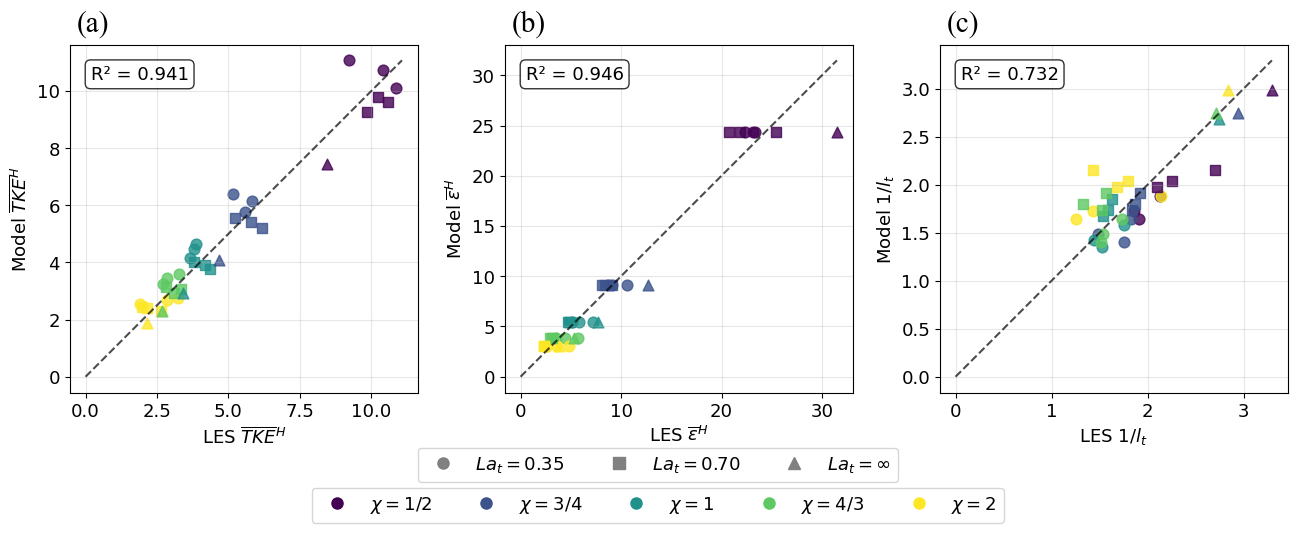

In [14]:

# ========================================================================
# Show the fitting results - Combined 3x3 subplot version
# ========================================================================
plt.rcParams['mathtext.fontset'] = 'cm'
# Show the TKE, dissipation, and invLength fitting results for given Laₜ, χ, and kH
# Case range
n_Laₜ = len(Laₜ_all)
n_χ = len(χ_all)
n_kH = len(kH_all)

# Create scatter plots comparing LES data vs model predictions
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
param_gs = dict(left=0.08, right=0.95, bottom=0.12, top=0.92, wspace=0.25)
plt.subplots_adjust(**param_gs)

# Set font
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 13

# Define markers for different Laₜ values
markers = ['o', 's', '^', 'D', 'v']  # Different markers for different Laₜ
# Define colors for different χ values  
colors = plt.cm.viridis(np.linspace(0, 1, len(χ_all)))
subplot_labels = ['(a)', '(b)', '(c)']


# Subplot 1: TKE scatter plot
ax = axes[0]
# Calculate all predicted TKE values
predicted_tke_all = np.zeros(len(tke32_les))
for i in range(len(tke32_les)):
    dissip_pred = dissip_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])
    invLength_pred = invLength_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])
    predicted_tke_all[i] = cf_g_tke * dissip_pred / invLength_pred

# Plot scatter points with different markers for Laₜ and colors for χ
for i in range(len(tke32_les)):
    # Find marker index for Laₜ
    lat_val = lat_fit_data[i]
    marker_idx = 0
    for idx, Laₜ in enumerate(Laₜ_all):
        if Laₜ == np.inf:
            if lat_val == 1000.0:
                marker_idx = idx
                break
        elif abs(lat_val - Laₜ) < 0.01:
            marker_idx = idx
            break
    
    # Find color index for χ
    chi_val = chi_fit_data[i]
    color_idx = np.argmin(np.abs(np.array([float(χ) for χ in χ_all]) - chi_val))
    
    ax.scatter(tke32_les[i]**(2/3), predicted_tke_all[i]**(2/3), 
               marker=markers[marker_idx], color=colors[color_idx], s=60, alpha=0.8)

# Add 1:1 line
max_val = max(np.max(tke32_les**(2/3)), np.max(predicted_tke_all**(2/3)))
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 line')
ax.set_xlabel(r'LES $\overline{TKE}^{H}$')
ax.set_ylabel(r'Model $\overline{TKE}^{H}$')
ax.text(0.02, 1.1, subplot_labels[0], transform=ax.transAxes, fontsize=21, fontname='Times New Roman' ,va='top')
ax.text(0.06, 0.9, f'R² = {R2_tke32:.3f}', transform=ax.transAxes, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Subplot 2: Dissipation scatter plot  
ax = axes[1]
# Calculate all predicted dissipation values
predicted_dissip_all = np.zeros(len(dissip_les))
for i in range(len(dissip_les)):
    predicted_dissip_all[i] = dissip_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])

# Plot scatter points
for i in range(len(dissip_les)):
    # Find marker index for Laₜ
    lat_val = lat_fit_data[i]
    marker_idx = 0
    for idx, Laₜ in enumerate(Laₜ_all):
        if Laₜ == np.inf:
            if lat_val == 1000.0:
                marker_idx = idx
                break
        elif abs(lat_val - Laₜ) < 0.01:
            marker_idx = idx
            break
    
    # Find color index for χ
    chi_val = chi_fit_data[i]
    color_idx = np.argmin(np.abs(np.array([float(χ) for χ in χ_all]) - chi_val))
    
    ax.scatter(dissip_les[i], predicted_dissip_all[i], 
               marker=markers[marker_idx], color=colors[color_idx], s=60, alpha=0.8)

# Add 1:1 line
max_val = max(np.max(dissip_les), np.max(predicted_dissip_all))
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 line')
ax.set_xlabel(r'LES $\overline{\epsilon}^{H}$')
ax.set_ylabel(r'Model $\overline{\epsilon}^{H}$')
ax.text(0.02, 1.1, subplot_labels[1], transform=ax.transAxes, fontsize=21, fontname='Times New Roman' ,va='top')
ax.text(0.06, 0.9, f'R² = {R2_dissip:.3f}', transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Subplot 3: invLength scatter plot
ax = axes[2]
# Calculate all predicted invLength values
predicted_invLength_all = np.zeros(len(invLength_les))
for i in range(len(invLength_les)):
    predicted_invLength_all[i] = invLength_model(chi_fit_data[i], lat_fit_data[i], kh_fit_data[i])

# Plot scatter points
for i in range(len(invLength_les)):
    # Find marker index for Laₜ
    lat_val = lat_fit_data[i]
    marker_idx = 0
    for idx, Laₜ in enumerate(Laₜ_all):
        if Laₜ == np.inf:
            if lat_val == 1000.0:
                marker_idx = idx
                break
        elif abs(lat_val - Laₜ) < 0.01:
            marker_idx = idx
            break
    
    # Find color index for χ
    chi_val = chi_fit_data[i]
    color_idx = np.argmin(np.abs(np.array([float(χ) for χ in χ_all]) - chi_val))
    
    ax.scatter(invLength_les[i], predicted_invLength_all[i], 
               marker=markers[marker_idx], color=colors[color_idx], s=60, alpha=0.8)

# Add 1:1 line
max_val = max(np.max(invLength_les), np.max(predicted_invLength_all))
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 line')
ax.set_xlabel(r'LES $1/l_t$')
ax.set_ylabel(r'Model $1/l_t$')
ax.text(0.02, 1.1, subplot_labels[2], transform=ax.transAxes, fontsize=21, fontname='Times New Roman' ,va='top')
ax.text(0.06, 0.9, f'R² = {R2_invLength:.3f}', transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Create custom legends
# Legend for Laₜ values
legend_elements_lat = []
for idx, Laₜ in enumerate(Laₜ_all):
    if Laₜ == np.inf:
        label = r'$La_t = \infty$'
    else:
        label = r'$La_t = {:.2f}$'.format(Laₜ)
    legend_elements_lat.append(plt.Line2D([0], [0], marker=markers[idx], color='gray', 
                                        linestyle='None', markersize=8, label=label))

# Legend for χ values
legend_elements_chi = []
for idx, χ in enumerate(χ_all):
    legend_elements_chi.append(plt.Line2D([0], [0], marker='o', color=colors[idx], 
                                        linestyle='None', markersize=8, 
                                        label=r'$\chi = {}$'.format(str(χ))))

# Add legends to the figure
fig.legend(handles=legend_elements_lat, loc='upper center', 
           bbox_to_anchor=(0.5, 0.08), ncol=len(Laₜ_all), frameon=True)
fig.legend(handles=legend_elements_chi, loc='upper center', 
           bbox_to_anchor=(0.5, 0), ncol=len(χ_all), frameon=True)

plt.savefig('./figure/new_fitting_scatter_05H_1by1.png', dpi=300, bbox_inches='tight')
plt.show()


### fitting 0.5H and H

In [1]:
#!/usr/bin/env python3
"""
Program: TKEmodel_integrated

Fit TKE and dissipation data using scipy.optimize.minimize.
Integrates both Full Depth (Mean) and 0.5H (Index 50) analysis into a single pipeline,
and plots the comparison side-by-side.
"""

import os
import pandas as pd
import numpy as np
from fractions import Fraction
from data.model.lsclib import caseClass
from scipy.optimize import minimize
import matplotlib.pyplot as plt

os.makedirs("./figure", exist_ok=True)

# ========================================================================
# User-specified Variables
# ========================================================================
path_data = "./data"
bn_data = "statistics.feather"
fmt_key = "Lat{Lat:s}_X{X:s}_kH{kH:s}"

Laₜ_all = (0.35, 0.7, np.inf)
χ_all = (Fraction(1, 2), Fraction(3, 4), Fraction(1, 1), Fraction(4, 3), Fraction(2, 1))
kH_all = (Fraction(5, 2), Fraction(5, 1), Fraction(10, 1)) 
ustar_all = (0.01214, 0.00857, 0.00605) # m/s
H = 25 # m
nz = 101
dz_nd = 1 / (nz - 1)
key_col = ["tke+", "P+", "dissip+"]

# Turbulence constant for Full Depth TKE
C_mu = 0.09
C_mu_34 = C_mu ** (3.0 / 4.0)

# ========================================================================
# User-defined Functions
# ========================================================================
def cal_xs(χ):
    return 1+1/χ**3

def h2l(cf_a, cf_b, cf_c, cf_d, Lat, kH, x):
    chi_term = x + 1.0 / x
    main_term = cf_a - cf_b / chi_term
    Lat2 = max(Lat**2, 1e-12)
    lat_term = cf_c * (kH / Lat2 + cf_d) / (1.0 + 1.0 / Lat2)
    return main_term + lat_term

def dissip_model_func(chi, lat, kh, coef_dissip):
    xs = cal_xs(chi)
    return coef_dissip * xs

def invLength_model_func(chi, lat, kh, cf_a, cf_b, cf_c, cf_d):
    return h2l(cf_a, cf_b, cf_c, cf_d, lat, kh, chi)

def objective_dissip(params, xs_data, dissip_data):
    coef = params[0]
    predicted = coef * xs_data
    return np.sum((dissip_data - predicted)**2)

def objective_invLength(params, chi_data, lat_data, kh_data, invLength_data):
    cf_a, cf_b, cf_c, cf_d = params
    predicted = np.zeros_like(invLength_data)
    for i in range(len(invLength_data)):
        predicted[i] = h2l(cf_a, cf_b, cf_c, cf_d, lat_data[i], kh_data[i], chi_data[i])
    return np.sum((invLength_data - predicted)**2)

def objective_tke32(params, chi_data, lat_data, kh_data, tke32_data, dissip_model, invLength_model):
    cf_g = params[0]
    predicted = np.zeros_like(tke32_data)
    for i in range(len(tke32_data)):
        dissip_pred = dissip_model(chi_data[i], lat_data[i], kh_data[i])
        invLength_pred = invLength_model(chi_data[i], lat_data[i], kh_data[i])
        predicted[i] = cf_g * dissip_pred / (invLength_pred + 1e-8)
    return np.sum((tke32_data - predicted)**2)

def calculate_r2(observed, predicted):
    SS_res = np.sum((observed - predicted)**2)
    SS_tot = np.sum((observed - np.mean(observed))**2)
    return 1 - SS_res / SS_tot

# ========================================================================
# 1. Extract Data for BOTH Full Depth (Mean) and 0.5H
# ========================================================================
case_all = dict()
for Laₜ in Laₜ_all:
    for χ in χ_all:
        if Laₜ == np.inf:
            case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
            case_all[case.key_case] = case
            case_all[case.key_case].xs = cal_xs(χ)
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(Laₜ, χ, kH, ustar_all[ik], H)
                case_all[case.key_case] = case
                case_all[case.key_case].xs = cal_xs(χ)

fmt_fn = os.path.join(path_data, "{case:s}", bn_data)
for case in case_all:
    data_col = pd.read_feather(fmt_fn.format(case=case))[key_col]

    # --- Full Depth (Mean) ---
    df_mean = pd.DataFrame()
    df_mean['P+'] = data_col['P+']
    df_mean['tke32+_lt'] = data_col['tke+']
    df_mean['dissip+_lt'] = data_col['dissip+']
    df_mean['tke32+'] = data_col['tke+']
    df_mean['dissip+'] = data_col['dissip+']
    
    df_mean = df_mean.mean()
    df_mean['tke32+'] **= 3/2
    df_mean['tke32+_lt'] **= 3/2
    case_all[case].data_mean = df_mean

    # --- 0.5H (Index 50) ---
    dict_half = pd.DataFrame()
    dict_half['P+'] = data_col['P+']
    dict_half['tke32+_lt'] = data_col['tke+']
    dict_half['dissip+_lt'] = data_col['dissip+']
    dict_half['tke32+'] = data_col['tke+'][50]
    dict_half['dissip+'] = data_col['dissip+'][50]

    dict_half = dict_half.mean()
    dict_half['tke32+'] **= 3/2
    dict_half['tke32+_lt'] **= 3/2
    case_all[case].data_half = dict_half

# Helper function to convert dict to arrays
def get_arrays(case_dict, mode="mean"):
    n = len(case_dict)
    xs, tke32, dissip, invLength = np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n)
    chi_arr, lat_arr, kh_arr = [], [], []
    
    for i, c in enumerate(case_dict):
        xs[i] = case_dict[c].xs
        data = case_dict[c].data_mean if mode == "mean" else case_dict[c].data_half
        
        tke32[i] = data['tke32+']
        dissip[i] = data['dissip+']
        
        # Calculate invLength
        if mode == "mean":
            l_t = C_mu_34 * data['tke32+_lt'] / data['dissip+_lt']
        else:
            l_t = data['tke32+_lt'] / data['dissip+_lt']
        invLength[i] = 1.0 / l_t
        
        c_obj = case_dict[c]
        chi_arr.append(float([χ for χ in χ_all if c_obj.χ == χ][0]))
        lat_arr.append(float(c_obj.Laₜ) if c_obj.Laₜ != np.inf else 1000.0)
        kh_arr.append(float(c_obj.kH) if c_obj.Laₜ != np.inf else 0.0)
        
    return xs, tke32, dissip, invLength, np.array(chi_arr), np.array(lat_arr), np.array(kh_arr)

# ========================================================================
# 2. Fit Models
# ========================================================================

def run_fitting(mode="mean"):
    print(f"\n{'='*40}\nRunning fitting for {mode.upper()}\n{'='*40}")
    xs_les, tke32_les, dissip_les, invLength_les, chi_fit, lat_fit, kh_fit = get_arrays(case_all, mode)
    
    results = {'obs_dissip': dissip_les, 'obs_invLength': invLength_les, 'obs_tke32': tke32_les}
    
    # 2.1 Dissipation
    res_dissip = minimize(objective_dissip, [10.0], args=(xs_les, dissip_les), method='L-BFGS-B', bounds=[(0.1, 50.0)])
    coef_dissip = res_dissip.x[0] if res_dissip.success else 10.0
    results['pred_dissip'] = coef_dissip * xs_les
    results['R2_dissip'] = calculate_r2(dissip_les, results['pred_dissip'])
    
    # 2.2 invLength
    res_inv = minimize(objective_invLength, [15.0, 18.0, 0.26, 38.0], 
                       args=(chi_fit, lat_fit, kh_fit, invLength_les), 
                       method='L-BFGS-B', bounds=[(0.0, 50.0), (-50.0, 50.0), (-20.0, 20.0), (0.0, 200.0)])
    cf_a, cf_b, cf_c, cf_d = res_inv.x if res_inv.success else [15.0, 18.0, 0.26, 38.0]
    
    results['pred_invLength'] = np.array([h2l(cf_a, cf_b, cf_c, cf_d, lat_fit[i], kh_fit[i], chi_fit[i]) for i in range(len(chi_fit))])
    results['R2_invLength'] = calculate_r2(invLength_les, results['pred_invLength'])
    
    # 2.3 TKE 
    def d_mod(c, l, k): return dissip_model_func(c, l, k, coef_dissip)
    def i_mod(c, l, k): return invLength_model_func(c, l, k, cf_a, cf_b, cf_c, cf_d)
    
    if mode == "mean":
        # Fixed C_mu for mean
        results['pred_tke32'] = np.array([d_mod(chi_fit[i], lat_fit[i], kh_fit[i]) / (i_mod(chi_fit[i], lat_fit[i], kh_fit[i]) * C_mu_34) for i in range(len(chi_fit))])
    else:
        # Fit cf_g for 0.5H
        res_tke = minimize(objective_tke32, [1.0], args=(chi_fit, lat_fit, kh_fit, tke32_les, d_mod, i_mod), 
                           method='L-BFGS-B', bounds=[(1e-5, 1000.0)])
        cf_g = res_tke.x[0] if res_tke.success else 1.0
        results['pred_tke32'] = np.array([cf_g * d_mod(chi_fit[i], lat_fit[i], kh_fit[i]) / (i_mod(chi_fit[i], lat_fit[i], kh_fit[i]) + 1e-8) for i in range(len(chi_fit))])
        print(f"[{mode}] Fitted cf_g = {cf_g:.4f}, Equiv C_mu = {cf_g**(-4/3):.4f}, {cf_g*C_mu_34:.3f}")
        
    results['R2_tke32'] = calculate_r2(tke32_les, results['pred_tke32'])
    
    print(f"[{mode}] R2 Dissipation: {results['R2_dissip']:.4f}")
    print(f"[{mode}] R2 invLength: {results['R2_invLength']:.4f}")
    print(f"[{mode}] R2 TKE3/2: {results['R2_tke32']:.4f}")
    print(f"  c_a = {cf_a:.3f}")
    print(f"  c_b = {cf_b:.3f}")
    print(f"  c_c = {cf_c:.3f}")
    print(f"  c_d = {cf_d:.3f}")
    return results

res_mean = run_fitting("mean")
res_half = run_fitting("half")



Running fitting for MEAN
[mean] R2 Dissipation: 0.9882
[mean] R2 invLength: 0.7330
[mean] R2 TKE3/2: 0.9546
  c_a = 15.574
  c_b = 18.286
  c_c = 0.259
  c_d = 38.002

Running fitting for HALF
[half] Fitted cf_g = 2.4986, Equiv C_mu = 0.2949, 0.411
[half] R2 Dissipation: 0.9461
[half] R2 invLength: 0.7319
[half] R2 TKE3/2: 0.9413
  c_a = 2.601
  c_b = 3.015
  c_c = 0.036
  c_d = 44.647


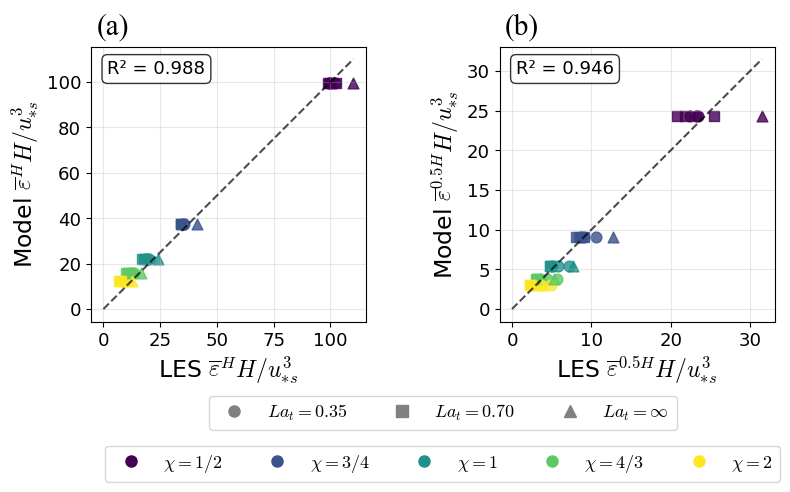

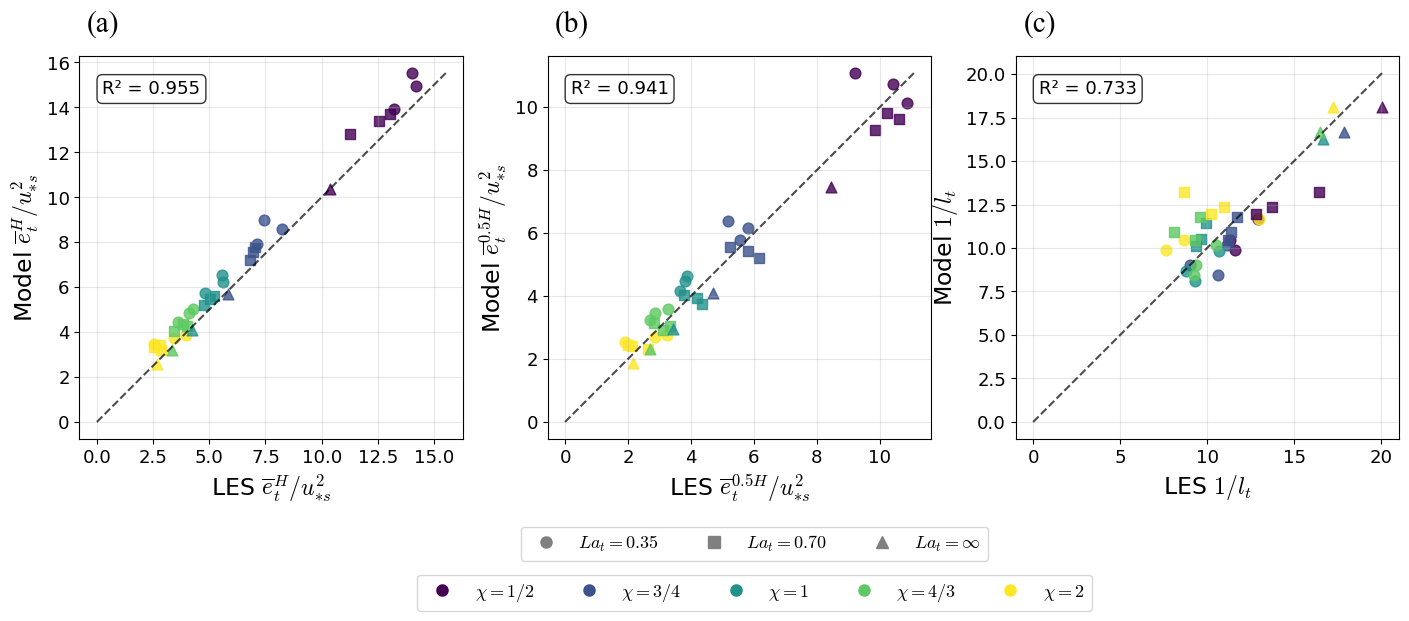

In [3]:
# ========================================================================
# 4. 论文级绘图展示 (基于用户指定的风格)
# ========================================================================

# 设置全局字体
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 13
plt.rcParams['mathtext.fontset'] = 'cm'
# 提取用于匹配 marker 和 color 的基础数据数组
lat_fit_data = []
chi_fit_data = []
for c in case_all:
    c_obj = case_all[c]
    lat_fit_data.append(float(c_obj.Laₜ) if c_obj.Laₜ != np.inf else 1000.0)
    chi_fit_data.append(float([χ for χ in χ_all if c_obj.χ == χ][0]))
lat_fit_data = np.array(lat_fit_data)
chi_fit_data = np.array(chi_fit_data)

# 标记与颜色设置
markers = ['o', 's', '^', 'D', 'v']
colors = plt.cm.viridis(np.linspace(0, 1, len(χ_all)))

# 通用绘制单个子图的函数
def plot_styled_scatter(ax, obs, pred, r2, title, xlabel, ylabel, subplot_label,size=17):
    for i in range(len(obs)):
        # 寻找对应的 marker (匹配 La_t)
        lat_val = lat_fit_data[i]
        marker_idx = 0
        for idx, Laₜ in enumerate(Laₜ_all):
            if Laₜ == np.inf and lat_val == 1000.0:
                marker_idx = idx
                break
            elif abs(lat_val - float(Laₜ)) < 0.01:
                marker_idx = idx
                break
        
        # 寻找对应的 color (匹配 chi)
        chi_val = chi_fit_data[i]
        color_idx = np.argmin(np.abs(np.array([float(χ) for χ in χ_all]) - chi_val))
        
        ax.scatter(obs[i], pred[i], marker=markers[marker_idx], color=colors[color_idx], s=60, alpha=0.8)

    # 1:1 线
    max_val = max(np.max(obs), np.max(pred))
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 line')
    
    # 标签与文本
    ax.set_title(title, pad=15)
    ax.set_xlabel(xlabel,fontsize=size)
    ax.set_ylabel(ylabel,fontsize=size)
    ax.text(0.02, 1.12, subplot_label, transform=ax.transAxes, fontsize=21, fontname='Times New Roman', va='top')
    ax.text(0.06, 0.9, f'R² = {r2:.3f}', transform=ax.transAxes, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

# 生成公共图例的函数
def add_custom_legends(fig, bbox_y1, bbox_y2):
    legend_elements_lat = []
    for idx, Laₜ in enumerate(Laₜ_all):
        label = r'$La_t = \infty$' if Laₜ == np.inf else r'$La_t = {:.2f}$'.format(Laₜ)
        legend_elements_lat.append(plt.Line2D([0], [0], marker=markers[idx], color='gray', 
                                            linestyle='None', markersize=8, label=label))

    legend_elements_chi = []
    for idx, χ in enumerate(χ_all):
        legend_elements_chi.append(plt.Line2D([0], [0], marker='o', color=colors[idx], 
                                            linestyle='None', markersize=8, label=r'$\chi = {}$'.format(str(χ))))

    fig.legend(handles=legend_elements_lat, loc='upper center', bbox_to_anchor=(0.5, bbox_y1), ncol=len(Laₜ_all), frameon=True)
    fig.legend(handles=legend_elements_chi, loc='upper center', bbox_to_anchor=(0.5, bbox_y2), ncol=len(χ_all), frameon=True)


# ========================================================================
# FIGURE 1: 仅包含耗散率 (Dissipation) - 1行2列
# ========================================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(10, 5))
plt.subplots_adjust(left=0.1, right=0.88, bottom=0.25, top=0.8, wspace=0.1)

# (a) 全水深 Dissipation
plot_styled_scatter(axes1[0], res_mean['obs_dissip'], res_mean['pred_dissip'], res_mean['R2_dissip'], 
                    " ", r'LES $\overline{\varepsilon}^{H}H/u_{*s}^{3}$', r'Model $\overline{\varepsilon}^{H}H/u_{*s}^{3}$', "(a)")

# (b) 半水深 Dissipation
plot_styled_scatter(axes1[1], res_half['obs_dissip'], res_half['pred_dissip'], res_half['R2_dissip'], 
                    " ", r'LES $\overline{\varepsilon}^{0.5H}H/u_{*s}^{3}$', r'Model $\overline{\varepsilon}^{0.5H}H/u_{*s}^{3}$', "(b)")

add_custom_legends(fig1, 0.12, 0.02)
plt.savefig('./figure/fitting_scatter_dissipation.png', dpi=300, bbox_inches='tight')
plt.show()


# ========================================================================
# FIGURE 2: 包含 TKE 与 长度尺度 (invLength) - 2行2列
# ========================================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 6))
plt.subplots_adjust(left=0.05, right=0.93, bottom=0.18, top=0.92, wspace=0.22, hspace=0.3)

# 转换 TKE3/2 为 TKE (通过 2/3 次方)
obs_tke_mean = res_mean['obs_tke32'] ** (2/3)
pred_tke_mean = res_mean['pred_tke32'] ** (2/3)
obs_tke_half = res_half['obs_tke32'] ** (2/3)
pred_tke_half = res_half['pred_tke32'] ** (2/3)

# (a) 全水深 TKE
plot_styled_scatter(axes2[0], obs_tke_mean, pred_tke_mean, res_mean['R2_tke32'], 
                    " ", r'LES $\overline{e}_t^{H}/u_{*s}^{2}$', r'Model $\overline{e}_t^{H}/u_{*s}^{2}$', "(a)")

# (b) 半水深 TKE
plot_styled_scatter(axes2[1], obs_tke_half, pred_tke_half, res_half['R2_tke32'], 
                    " ", r'LES $\overline{e}_t^{0.5H}/u_{*s}^{2}$', r'Model $\overline{e}_t^{0.5H}/u_{*s}^{2}$', "(b)")

# (c) 全水深 invLength
plot_styled_scatter(axes2[2], res_mean['obs_invLength'], res_mean['pred_invLength'], res_mean['R2_invLength'], 
                    " ", r'LES $1/l_t$', r'Model $1/l_t$', "(c)")

# # (d) 半水深 invLength
# plot_styled_scatter(axes2[1, 1], res_half['obs_invLength'], res_half['pred_invLength'], res_half['R2_invLength'], 
#                     " ", r'LES $1/l_t$', r'Model $1/l_t$', "(d)")

add_custom_legends(fig2, 0.1, 0.02)
plt.savefig('./figure/fitting_scatter_tke_invL.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# Prerequisite Module
import os
import pandas as pd
import numpy as np
from fractions import Fraction
from data.model.lsclib import caseClass, find_caseKey
from scipy import linalg
from scipy.optimize import minimize
import matplotlib as mpl
import matplotlib.pyplot as plt

# User-specified Variable (copied from TKELengthPlot.py)
# File
path_data = "./data"
bn_data = "statistics.feather"
fmt_key = "Lat{Lat:s}_X{X:s}_kH{kH:s}"

# Case
Laₜ_all = (0.35, 0.7, np.inf)
χ_all = (Fraction(1, 2), Fraction(3, 4), Fraction(1, 1), Fraction(4, 3), Fraction(2, 1))
kH_all = (Fraction(5, 2), Fraction(5, 1), Fraction(10, 1)) 
ustar_all = (0.01214, 0.00857, 0.00605) # m/s
H = 25 # m
κ = 0.012 # for tke32, kappa = 0.022 is the best

# Data
key_col = ["cov_ww+", "tke+", "P+", "dissip+"]
nz = 101
H = 25 # m
Δt = 120 # second
dz_nd = 1 / (nz - 1)


# Read TKE data for each case (copied from TKELengthPlot.py)
# Create case containers
case_all = dict()
for Laₜ in Laₜ_all:
    for χ in χ_all:
        if Laₜ == np.inf:
            case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
            case_all[case.key_case] = case
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(Laₜ, χ, kH, ustar_all[ik], H)
                case_all[case.key_case] = case

case_all2 = dict()
for Laₜ in Laₜ_all:
    for χ in χ_all:
        if Laₜ == np.inf:
            case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
            case_all2[case.key_case] = case
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(Laₜ, χ, kH, ustar_all[ik], H)
                case_all2[case.key_case] = case

# Read all data (copied from TKELengthPlot.py)
fmt_fn = os.path.join(path_data, "{case:s}", bn_data)
for case in case_all:
    data_col = pd.read_feather(fmt_fn.format(case=case))[key_col]

    case_all[case].data = pd.DataFrame()
    case_all[case].data['tke32+'] = data_col['tke+']
    case_all[case].data['dissip+'] = data_col['dissip+']

    case_all[case].data = case_all[case].data.mean()
    case_all[case].data['tke32+'] **= 3/2

    case_all2[case].data = pd.DataFrame()
    case_all2[case].data['P+'] = data_col['P+']
    case_all2[case].data['tke32+'] = data_col['tke+'][50]
    case_all2[case].data['dissip+'] = data_col['dissip+'][50]

    case_all2[case].data = case_all2[case].data.mean()
    case_all2[case].data['tke32+'] **= 3/2

# Fitting data to derived models (copied from TKELengthPlot.py)
# Re-organize data to array-type for fitting
# Declare data variable
ndim = len(case_all)
tke32_les_H = np.zeros(ndim)
dissip_les_H = np.zeros(ndim)
tke32_les_05H = np.zeros(ndim)
dissip_les_05H = np.zeros(ndim)

# Extract data values from data containers
for ic, case in enumerate(case_all):
    tke32_les_H[ic] = case_all[case].data['tke32+']
    dissip_les_H[ic] = case_all[case].data['dissip+']
    tke32_les_05H[ic] = case_all2[case].data['tke32+']
    dissip_les_05H[ic] = case_all2[case].data['dissip+']

R2_tke32_05H_H = calculate_r2(tke32_les_05H, tke32_les_H)
R2_dissip_05H_H = calculate_r2(dissip_les_05H, dissip_les_H)

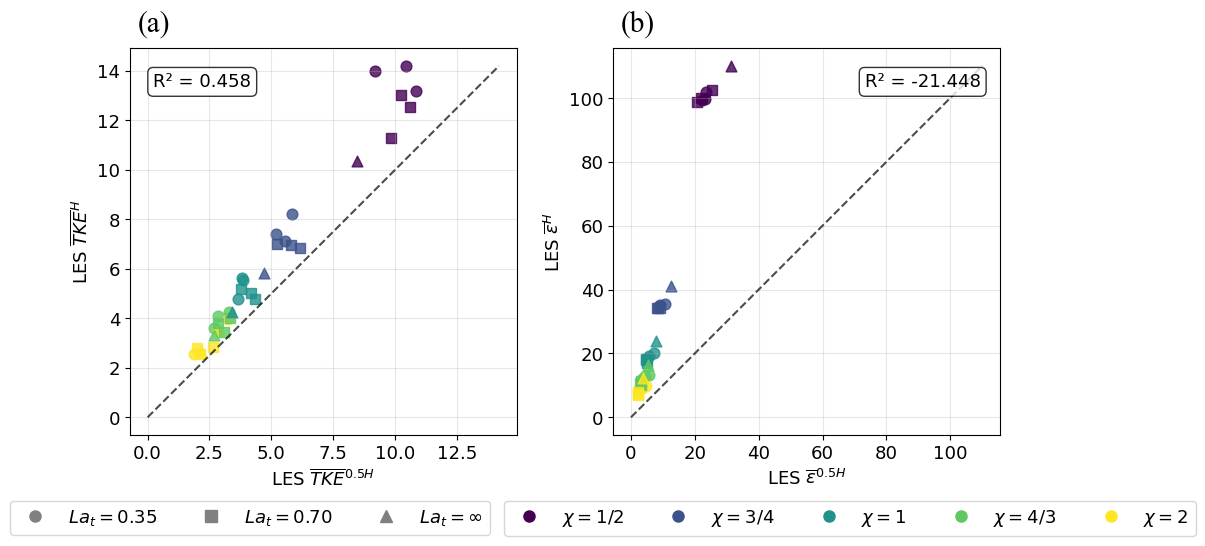

In [23]:

# ========================================================================
# Show the fitting results - Combined 3x3 subplot version
# ========================================================================

# Show the TKE, dissipation, and invLength fitting results for given Laₜ, χ, and kH
# Case range
n_Laₜ = len(Laₜ_all)
n_χ = len(χ_all)
n_kH = len(kH_all)

# Create scatter plots comparing LES data vs model predictions
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
param_gs = dict(left=0.08, right=0.95, bottom=0.12, top=0.92, wspace=0.25)
plt.subplots_adjust(**param_gs)

# Set font
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 13

# Define markers for different Laₜ values
markers = ['o', 's', '^', 'D', 'v']  # Different markers for different Laₜ
# Define colors for different χ values  
colors = plt.cm.viridis(np.linspace(0, 1, len(χ_all)))
subplot_labels = ['(a)', '(b)', '(c)']


# Subplot 1: TKE scatter plot
ax = axes[0]

# Plot scatter points with different markers for Laₜ and colors for χ
for i in range(len(tke32_les)):
    # Find marker index for Laₜ
    lat_val = lat_fit_data[i]
    marker_idx = 0
    for idx, Laₜ in enumerate(Laₜ_all):
        if Laₜ == np.inf:
            if lat_val == 1000.0:
                marker_idx = idx
                break
        elif abs(lat_val - Laₜ) < 0.01:
            marker_idx = idx
            break
    
    # Find color index for χ
    chi_val = chi_fit_data[i]
    color_idx = np.argmin(np.abs(np.array([float(χ) for χ in χ_all]) - chi_val))
    
    ax.scatter(tke32_les_05H[i]**(2/3), tke32_les_H[i]**(2/3), 
               marker=markers[marker_idx], color=colors[color_idx], s=60, alpha=0.8)

# Add 1:1 line
max_val = max(np.max(tke32_les_05H**(2/3)), np.max(tke32_les_H**(2/3)))
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 line')
ax.set_xlabel(r'LES $\overline{TKE}^{0.5H}$')
ax.set_ylabel(r'LES $\overline{TKE}^{H}$')
ax.text(0.02, 1.1, subplot_labels[0], transform=ax.transAxes, fontsize=21, fontname='Times New Roman' ,va='top')
ax.text(0.06, 0.9, f'R² = {R2_tke32_05H_H:.3f}', transform=ax.transAxes, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Subplot 2: Dissipation scatter plot  
ax = axes[1]

# Plot scatter points
for i in range(len(dissip_les)):
    # Find marker index for Laₜ
    lat_val = lat_fit_data[i]
    marker_idx = 0
    for idx, Laₜ in enumerate(Laₜ_all):
        if Laₜ == np.inf:
            if lat_val == 1000.0:
                marker_idx = idx
                break
        elif abs(lat_val - Laₜ) < 0.01:
            marker_idx = idx
            break
    
    # Find color index for χ
    chi_val = chi_fit_data[i]
    color_idx = np.argmin(np.abs(np.array([float(χ) for χ in χ_all]) - chi_val))
    
    ax.scatter(dissip_les_05H[i], dissip_les_H[i], 
               marker=markers[marker_idx], color=colors[color_idx], s=60, alpha=0.8)

# Add 1:1 line
max_val = max(np.max(dissip_les_05H), np.max(dissip_les_H))
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.7, label='1:1 line')
ax.set_xlabel(r'LES $\overline{\epsilon}^{0.5H}$')
ax.set_ylabel(r'LES $\overline{\epsilon}^{H}$')
ax.text(0.02, 1.1, subplot_labels[1], transform=ax.transAxes, fontsize=21, fontname='Times New Roman' ,va='top')
ax.text(0.65, 0.9, f'R² = {R2_dissip_05H_H:.3f}', transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')


# Create custom legends
# Legend for Laₜ values
legend_elements_lat = []
for idx, Laₜ in enumerate(Laₜ_all):
    if Laₜ == np.inf:
        label = r'$La_t = \infty$'
    else:
        label = r'$La_t = {:.2f}$'.format(Laₜ)
    legend_elements_lat.append(plt.Line2D([0], [0], marker=markers[idx], color='gray', 
                                        linestyle='None', markersize=8, label=label))

# Legend for χ values
legend_elements_chi = []
for idx, χ in enumerate(χ_all):
    legend_elements_chi.append(plt.Line2D([0], [0], marker='o', color=colors[idx], 
                                        linestyle='None', markersize=8, 
                                        label=r'$\chi = {}$'.format(str(χ))))

# Add legends to the figure
fig.legend(handles=legend_elements_lat, loc='upper center', 
           bbox_to_anchor=(0.2, 0.02), ncol=len(Laₜ_all), frameon=True)
fig.legend(handles=legend_elements_chi, loc='upper center', 
           bbox_to_anchor=(0.8, 0.02), ncol=len(χ_all), frameon=True)

plt.savefig('./figure/LES_tke_dissip_scatter_05H_vs_H_1by1.png', dpi=300, bbox_inches='tight')
plt.show()
